In [1]:
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('../data/raw/train.csv', dtype={'StateHoliday': str}, parse_dates=['Date'], index_col='Date')
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1017209 entries, 2015-07-31 to 2013-01-01
Data columns (total 8 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   Store          1017209 non-null  int64
 1   DayOfWeek      1017209 non-null  int64
 2   Sales          1017209 non-null  int64
 3   Customers      1017209 non-null  int64
 4   Open           1017209 non-null  int64
 5   Promo          1017209 non-null  int64
 6   StateHoliday   1017209 non-null  str  
 7   SchoolHoliday  1017209 non-null  int64
dtypes: int64(7), str(1)
memory usage: 69.8 MB


In [3]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00
mean,558.43,4.00,5773.82,633.15,0.83,0.38,0.18
std,321.91,2.00,3849.93,464.41,0.38,0.49,0.38
min,1.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,280.00,2.00,3727.00,405.00,1.00,0.00,0.00
50%,558.00,4.00,5744.00,609.00,1.00,0.00,0.00
75%,838.00,6.00,7856.00,837.00,1.00,1.00,0.00
max,1115.00,7.00,41551.00,7388.00,1.00,1.00,1.00


Видим 1115 магазинов. Для упрощения анализа и построения моделей буду рассматривать подмножество магазинов.

У некоторых магазинов есть пропуски в 2014 году.

Возьму один магазин с полной историей и один с пропусками.

In [4]:
grouped = df.groupby('Store')['Sales'].count()
grouped

Store
1       942
2       942
3       942
4       942
5       942
       ... 
1111    942
1112    942
1113    942
1114    942
1115    942
Name: Sales, Length: 1115, dtype: int64

In [5]:
with_full_history = grouped[grouped == 942]
with_holes = grouped[grouped < 942]
print(with_full_history.head())
with_holes.head()

Store
1    942
2    942
3    942
4    942
5    942
Name: Sales, dtype: int64


Store
13    758
20    758
22    758
32    758
36    758
Name: Sales, dtype: int64

Выберу два магазина - 1 и 20

In [6]:
STORE_IDS = [1, 20]
data = df[df['Store'].isin(STORE_IDS)].sort_values(['Store', 'Date'])
data

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2013-01-01,1,2,0,0,0,0,a,1
2013-01-02,1,3,5530,668,1,0,0,1
2013-01-03,1,4,4327,578,1,0,0,1
2013-01-04,1,5,4486,619,1,0,0,1
2013-01-05,1,6,4997,635,1,0,0,1
...,...,...,...,...,...,...,...,...
2015-07-27,20,1,11255,1183,1,1,0,0
2015-07-28,20,2,10884,1048,1,1,0,0
2015-07-29,20,3,10728,1040,1,1,0,0


In [7]:
def check_misses_and_duplicates(data: pd.DataFrame) -> None:
    for store in STORE_IDS:
        store_df = data[data['Store'] == store]
        dates = store_df.index
        dates_range = pd.date_range(dates.min(), dates.max(), freq='D')
        missing = pd.Series(dates_range.difference(dates))
        duplicates = dates[dates.duplicated()]
        print(f'{store}: {len(dates)} строк, ожидается {len(dates_range)}')
        print(f'пропущенных дат: {len(missing)}')
        print(f'дублей дат: {len(duplicates)}')
        if len(missing):
            gap_id = (missing.diff() != pd.Timedelta(days=1)).cumsum()
            gaps = missing.groupby(gap_id).agg(['min', 'max', 'count'])
            print('Интервалы пропущенных строк:')
            for start, end, days in gaps.itertuples(index=False):
                print(f'{start.date()} - {end.date()} ({days} дн.)')
        print('-' * 50)

check_misses_and_duplicates(data)

1: 942 строк, ожидается 942
пропущенных дат: 0
дублей дат: 0
--------------------------------------------------
20: 758 строк, ожидается 942
пропущенных дат: 184
дублей дат: 0
Интервалы пропущенных строк:
2014-07-01 - 2014-12-31 (184 дн.)
--------------------------------------------------


In [8]:
print('Открыт, но 0 покупателей:', ((data['Open'] == 1) & (data['Customers'] == 0)).sum())
print('Закрыт, но есть покупатели:', ((data['Open'] == 0) & (data['Customers'] > 0)).sum())

Открыт, но 0 покупателей: 0
Закрыт, но есть покупатели: 0


Флаг `Open` полностью согласован с `Customers`: нет открытых дней без покупателей и закрытых дней с покупателями. Значит, закрытый день надёжно отличается от нулевого спроса, и по `Open` можно размечать пропуски.

## Признаки и свойства временного ряда

Сначала разберём, какие признаки есть в данных, затем проверим статистические свойства ряда покупателей: стационарность, автокорреляцию и периодичности.

Целевая переменная - `Customers`. В закрытый день `Customers` = 0, но это не спрос, а отсутствие работы, поэтому распределения считаем по открытым дням (`open_days`).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pywt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

sns.set_theme(style='whitegrid')
DAY_NAMES = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
DAY_LABELS = {
    i: f'{name} ({i})'
    for i, name in enumerate(['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье'], start=1)
}
MONTH_LABELS = {
    i: f'{name} ({i})'
    for i, name in enumerate(
        ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь',
         'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'],
        start=1,
    )
}
NUMERIC_FEATURES = ['Sales']
CATEGORICAL_FEATURES = ['DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

open_days = data[data['Open'] == 1]

### Пропуски и закрытые дни

In [10]:
closed = data[data['Open'] == 0]
reason = np.select(
    [closed['DayOfWeek'] == 7, closed['StateHoliday'] != '0'],
    ['воскресенье', 'госпраздник'],
    default='другое',
)
print(pd.crosstab(closed['Store'], reason))

closed[reason == 'другое']

col_0  воскресенье  госпраздник  другое
Store                                  
1              134           27       0
20             108           28       3


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2014-04-02,20,3,0,0,0,1,0,0
2014-04-03,20,4,0,0,0,1,0,0
2014-04-04,20,5,0,0,0,1,0,0


**Вывод.** Встречаются три случая, и обрабатывать их нужно по-разному:

1. **Плановое закрытие** - строка есть, `Open = 0`: все воскресенья и госпраздники. График известен заранее: в прогнозе это 0, в обучении и метриках такие дни не участвуют.
2. **Внеплановое закрытие** - магазин 20 не работал 2-4 апреля 2014 года (среда-пятница, не праздник, при этом шло промо). Скорее всего это ремонт или что-то в этом роде. Предсказать такое нельзя, поэтому в обучении эти дни тоже исключаем.
3. **Сбой выгрузки** - строки нет совсем: у магазина 20 пропущены даты с 2014-07-01 по 2014-12-31 (184 дня, найдено выше). Реальное число покупателей неизвестно, поэтому заполнять нулями нельзя: после восстановления календаря это `NaN` со статусом -1.


### Числовые признаки

Числовых колонок две: целевая `Customers` и выручка `Sales`. Смотрим их распределения рядом и связь между ними.

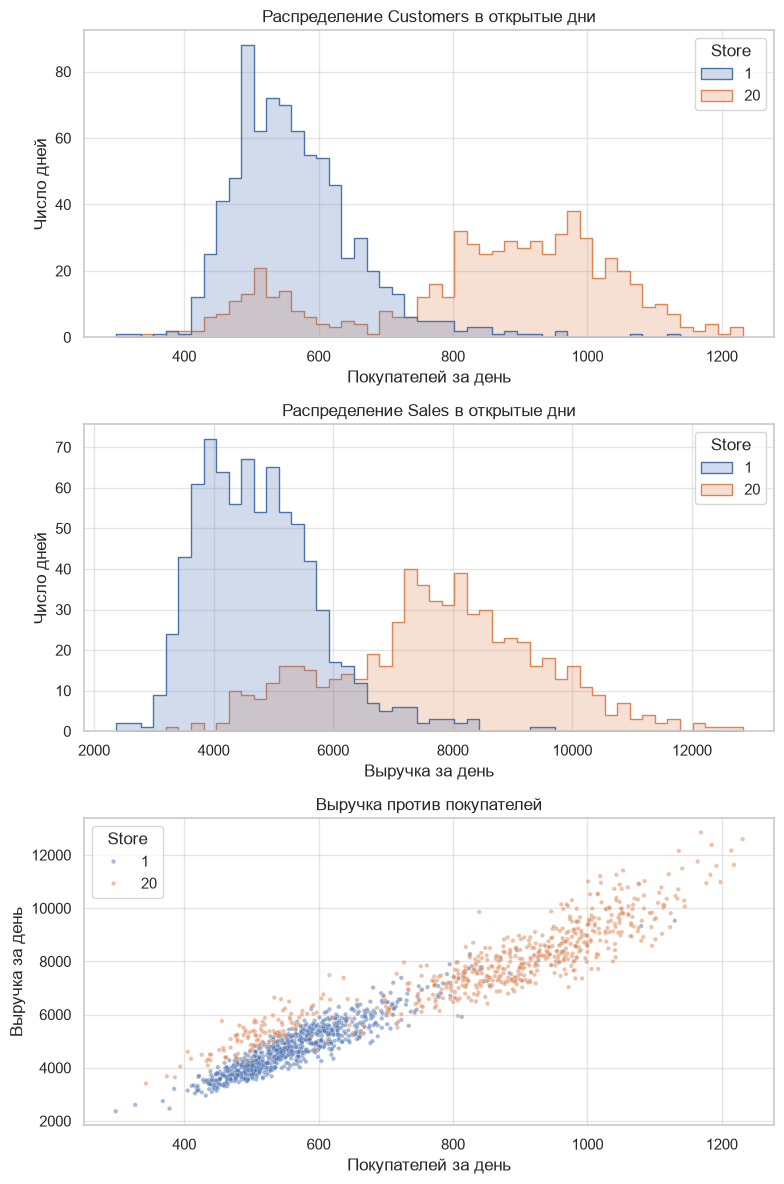

Корреляция Sales и Customers:
Store
1    0.93
20   0.92
Name: Sales, dtype: float64


Store                 1        20
Customers mean    564.05   848.56
          median  550.00   887.00
          std      93.71   190.34
          min     298.00   343.00
          max    1130.00  1231.00
          skew      1.32    -0.69
Sales     mean   4759.10  7756.94
          median 4647.00  7804.00
          std    1012.11  1695.43
          min    2362.00  3409.00
          max    9528.00 12849.00
          skew      0.93    -0.01

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))
labels = {'Customers': 'Покупателей за день', 'Sales': 'Выручка за день'}
for ax, col in zip(axes, ['Customers', 'Sales']):
    sns.histplot(
        data=open_days, x=col, hue=open_days['Store'].astype(str),
        bins=50, element='step', palette=['C0', 'C1'], ax=ax,
    )
    ax.set(title=f'Распределение {col} в открытые дни', xlabel=labels[col], ylabel='Число дней')

sns.scatterplot(
    data=open_days, x='Customers', y='Sales', hue=open_days['Store'].astype(str),
    palette=['C0', 'C1'], s=10, alpha=0.5, ax=axes[2],
)
axes[2].set(title='Выручка против покупателей', xlabel=labels['Customers'], ylabel=labels['Sales'])
for ax in axes:
    ax.legend_.set_title('Store')
plt.tight_layout()
plt.show()

print('Корреляция Sales и Customers:')
print(open_days.groupby('Store')[['Sales', 'Customers']].corr().xs('Customers', level=1)['Sales'].round(3))

open_days.groupby('Store')[['Customers', 'Sales']].agg(['mean', 'median', 'std', 'min', 'max', 'skew']).round(2).T

**Вывод.**

- Выручка и покупатели связаны почти линейно: корреляция 0.93 у магазина 1 и 0.92 у магазина 20.

**Для модели:** выручка становится известна только по итогам дня, поэтому признаком для прогноза на неделю вперёд она быть не может - на момент прогноза её ещё нет. Можно брать только прошлую выручку, но она почти дублирует прошлое число покупателей.

### Категориальные признаки

Доли значений считаем по всем дням, включая закрытые

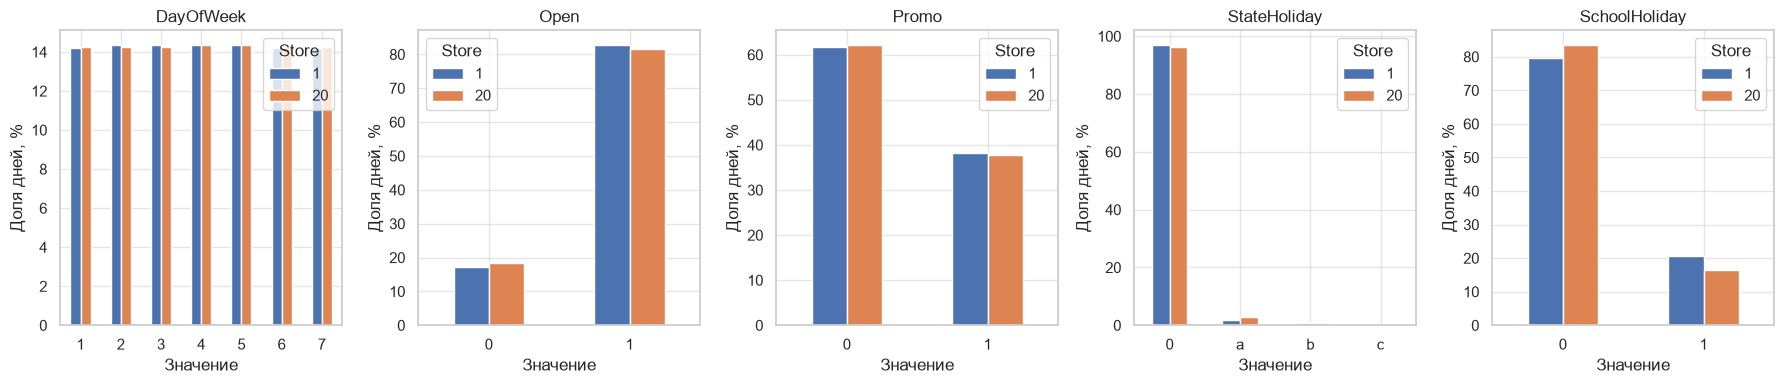

Store                     1     20
Признак       Значение            
DayOfWeek     1        14.20 14.20
              2        14.30 14.20
              3        14.30 14.20
              4        14.30 14.40
              5        14.30 14.40
              6        14.20 14.20
              7        14.20 14.20
Open          0        17.10 18.30
              1        82.90 81.70
Promo         0        61.80 62.30
              1        38.20 37.70
StateHoliday  0        97.10 96.20
              a         1.80  2.80
              b         0.60  0.80
              c         0.40  0.30
SchoolHoliday 0        79.50 83.60
              1        20.50 16.40

In [12]:
fig, axes = plt.subplots(1, len(CATEGORICAL_FEATURES), figsize=(18, 4))
for ax, col in zip(axes, CATEGORICAL_FEATURES):
    shares = data.groupby('Store')[col].value_counts(normalize=True).unstack(0) * 100
    shares.plot.bar(ax=ax, rot=0, color=['C0', 'C1'])
    ax.set(title=col, xlabel='Значение', ylabel='Доля дней, %')
    ax.legend(title='Store')
plt.tight_layout()
plt.show()

pd.concat(
    {col: data.groupby('Store')[col].value_counts(normalize=True).unstack(0) * 100 for col in CATEGORICAL_FEATURES},
    names=['Признак', 'Значение'],
).round(1)

**Вывод.**

- `Open`: магазины закрыты 17-18% дней - это воскресенья и праздники.
- `Promo` идёт в 38% дней.
- `StateHoliday`: праздников мало, 3-4% дней. `a` - обычный госпраздник, `b` - Пасха, `c` - Рождество; в эти дни магазины закрыты.
- `SchoolHoliday`: 16-21% дней.

**Для модели:** редкие категории `StateHoliday` по отдельности модель не выучит, поэтому хватит флагов «праздник» и «канун праздника». Промо встречается часто и регулярно, его эффект выучить можно.

### Динамика по времени

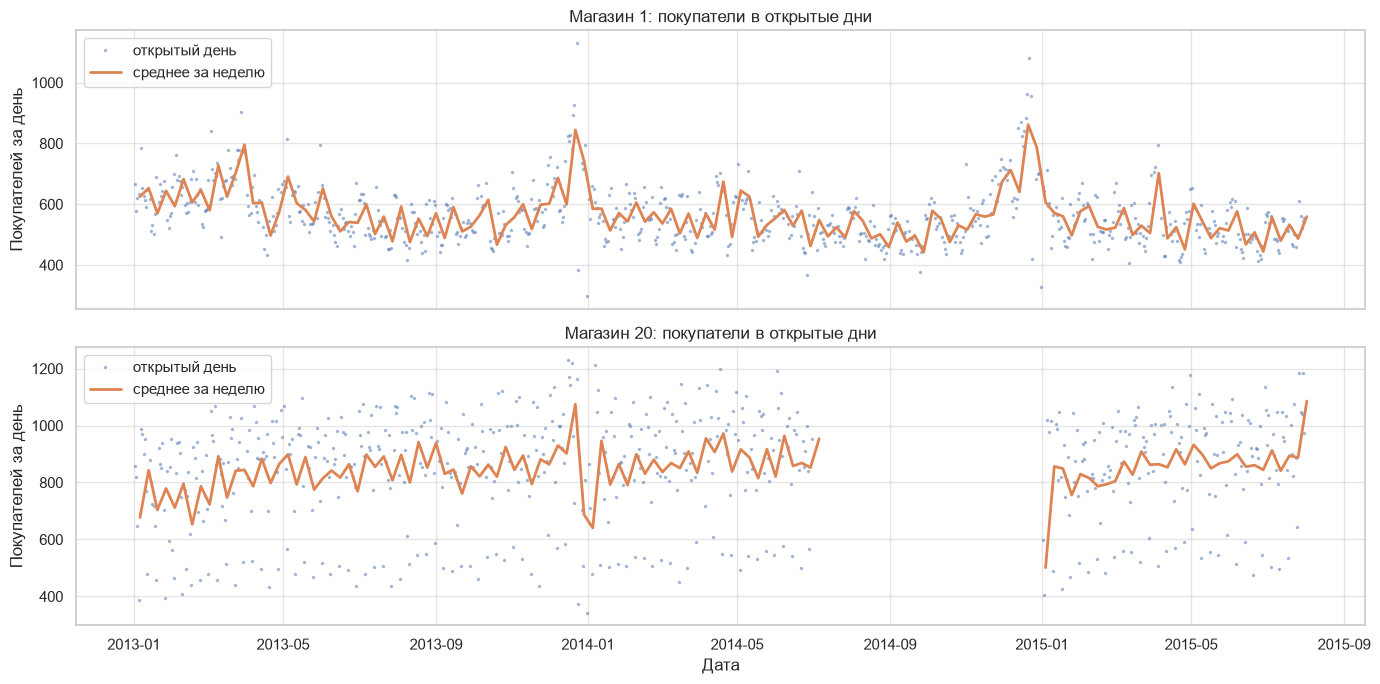

In [13]:
fig, axes = plt.subplots(len(STORE_IDS), 1, figsize=(14, 7), sharex=True)
for ax, store in zip(axes, STORE_IDS):
    customers = open_days.loc[open_days['Store'] == store, 'Customers']
    ax.plot(customers.index, customers, '.', ms=3, alpha=0.4, label='открытый день')
    ax.plot(customers.resample('W').mean(), lw=2, label='среднее за неделю')
    ax.set_title(f'Магазин {store}: покупатели в открытые дни')
    ax.set_ylabel('Покупателей за день')
    ax.legend(loc='upper left')
axes[-1].set_xlabel('Дата')
plt.tight_layout()
plt.show()

**Вывод.** У магазина 1 поток медленно снижается. Магазин 20 стабилен. У обоих всплески перед Рождеством и Пасхой, а у магазина 20 с июля по декабрь 2014 года данных нет вообще.

**Для модели:** уровень ряда дрейфует, поэтому признаки должны описывать недавнее прошлое (скользящие средние за последние недели), а не среднее за всю историю. После дыры у магазина 20 лаги первые недели будут пустыми.

### Недельная сезонность

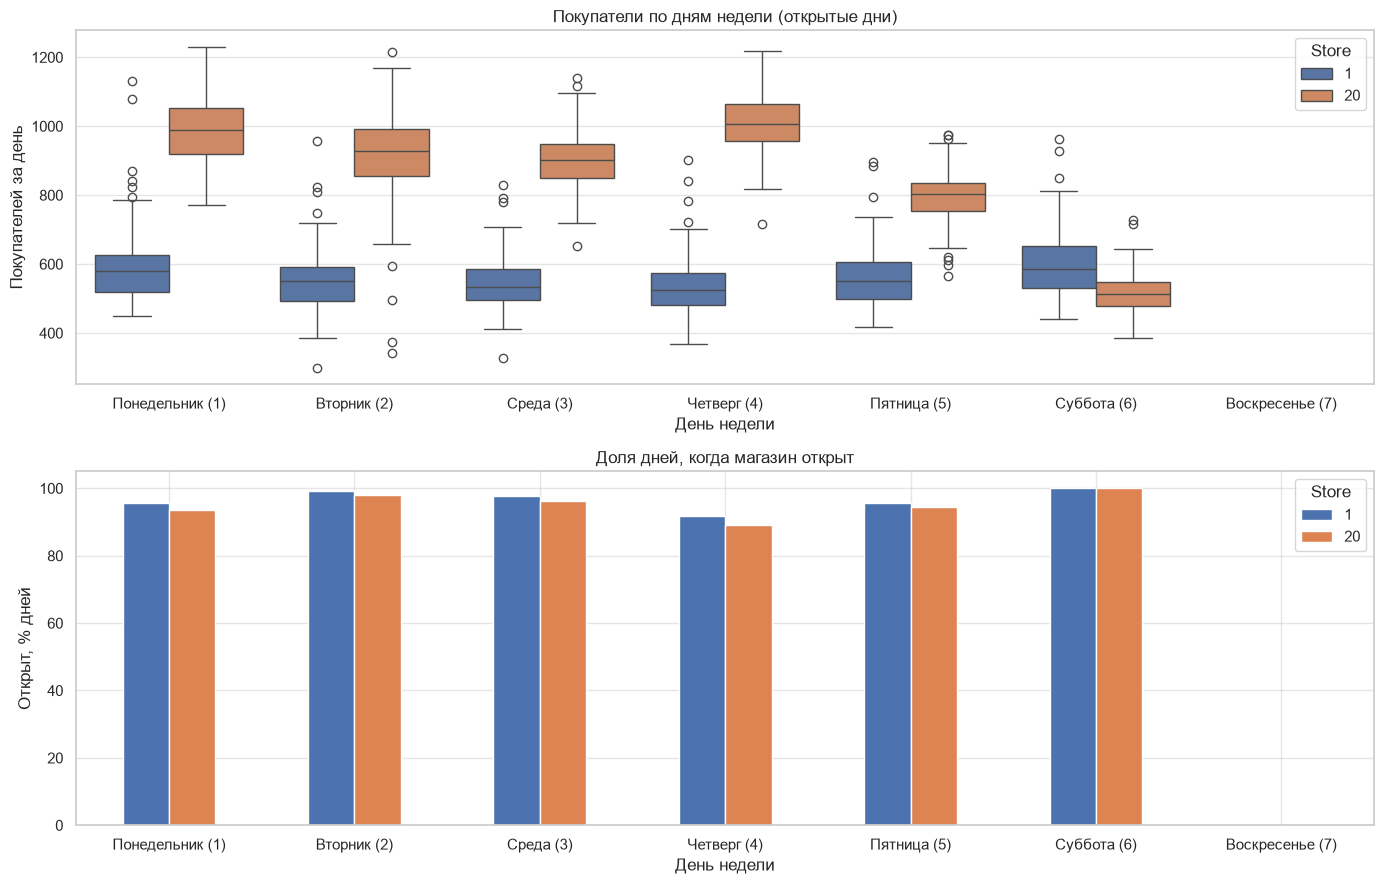

Store,1,20
День недели,,
Понедельник (1),581.00,989.00
Вторник (2),549.50,928.50
Среда (3),533.00,903.00
Четверг (4),525.00,1006.00
Пятница (5),552.00,802.00
Суббота (6),585.50,513.50


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

sns.boxplot(
    data=open_days, x='DayOfWeek', y='Customers', hue=open_days['Store'].astype(str),
    order=range(1, 8), palette=['C0', 'C1'], ax=axes[0],
)
axes[0].set_xticks(range(7), DAY_LABELS.values())
axes[0].set(title='Покупатели по дням недели (открытые дни)', xlabel='День недели', ylabel='Покупателей за день')
axes[0].legend(title='Store')

open_share = data.groupby(['DayOfWeek', 'Store'])['Open'].mean().unstack() * 100
open_share.index = open_share.index.map(DAY_LABELS)
open_share.plot.bar(ax=axes[1], rot=0, color=['C0', 'C1'])
axes[1].set(title='Доля дней, когда магазин открыт', xlabel='День недели', ylabel='Открыт, % дней')
axes[1].legend(title='Store')

plt.tight_layout()
plt.show()

(
    open_days.pivot_table(index='DayOfWeek', columns='Store', values='Customers', aggfunc='median')
    .rename(index=DAY_LABELS)
    .rename_axis(index='День недели')
)

**Вывод.** По воскресеньям оба магазина закрыты всегда. Чаще всего закрыто в четверг.
Недельные профили у магазинов противоположные: у магазина 1 пики в понедельник и субботу, у магазина 20 суббота почти вдвое слабее будней.

**Для модели:** день недели - главный сезонный фактор, и в каждом магазине он действует по-своему.

### Годовая сезонность

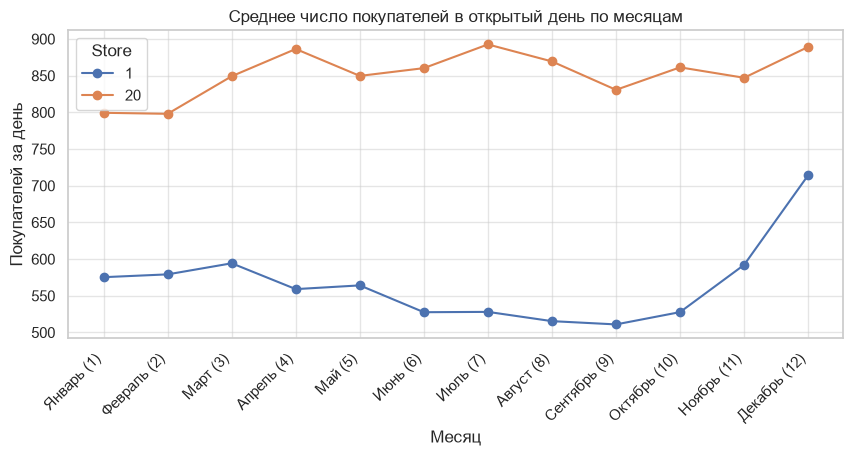

Store,1,20
Месяц,,
Январь (1),575.00,799.00
Февраль (2),579.00,798.00
Март (3),594.00,849.00
Апрель (4),559.00,886.00
Май (5),564.00,850.00
Июнь (6),528.00,860.00
Июль (7),528.00,893.00
Август (8),515.00,869.00
Сентябрь (9),511.00,831.00


In [15]:
monthly = open_days.groupby(['Store', open_days.index.month])['Customers'].mean().unstack(0)

ax = monthly.plot(marker='o', figsize=(10, 4))
ax.set(title='Среднее число покупателей в открытый день по месяцам', xlabel='Месяц', ylabel='Покупателей за день')
ax.set_xticks(range(1, 13), MONTH_LABELS.values(), rotation=45, ha='right')
ax.legend(title='Store')
plt.show()

monthly.rename(index=MONTH_LABELS).rename_axis(index='Месяц').round(0)

**Вывод.** Годовая сезонность заметна в основном у магазина 1: декабрь выше среднего месяца, а с июня по октябрь поток на ниже. У магазина 20 месяцы стабильнее.

**Для модели:** нужен признак месяца. Декабрей в данных всего два (2013 и 2014, у магазина 20 - один), поэтому рождественский пик лучше передать явными календарными признаками, чем надеяться, что модель выучит его по лагу в год.

### Промо

Промо планирует сеть, поэтому сначала смотрим, как оно устроено во времени: календарь промо-дней по неделям и автокорреляция флага `Promo`. Затем - сколько покупателей добавляет промо.

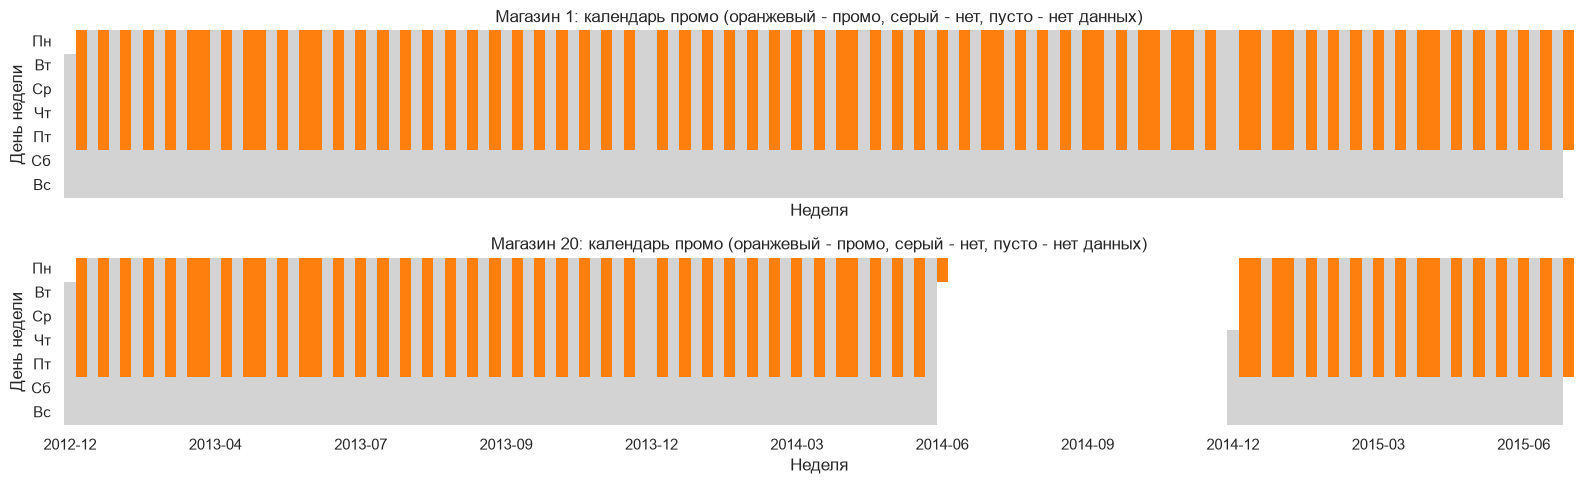

In [16]:
fig, axes = plt.subplots(len(STORE_IDS), 1, figsize=(16, 5), sharex=True)
for ax, store in zip(axes, STORE_IDS):
    promo = data.loc[data['Store'] == store, 'Promo'].asfreq('D')
    grid = (
        promo.to_frame('Promo')
        .assign(week=promo.index.to_period('W').start_time, dow=promo.index.dayofweek)
        .pivot(index='dow', columns='week', values='Promo')
    )
    sns.heatmap(grid, cmap=['lightgrey', 'tab:orange'], cbar=False, ax=ax)
    ax.grid(False)
    ax.set_yticks([d + 0.5 for d in range(7)], DAY_NAMES, rotation=0)
    ticks = range(0, grid.shape[1], 13)
    ax.set_xticks([t + 0.5 for t in ticks], [grid.columns[t].strftime('%Y-%m') for t in ticks], rotation=0)
    ax.set(
        title=f'Магазин {store}: календарь промо (оранжевый - промо, серый - нет, пусто - нет данных)',
        xlabel='Неделя', ylabel='День недели',
    )
plt.tight_layout()
plt.show()

In [17]:
rows = []
for store in STORE_IDS:
    promo = data.loc[data['Store'] == store, 'Promo'].asfreq('D')
    weekly = promo.resample('W').max().dropna()
    consecutive = weekly.index.to_series().diff().eq(pd.Timedelta(weeks=1))
    switched = weekly.diff().abs().eq(1)[consecutive]
    rows.append({
        'Store': store,
        **{f'автокорреляция, лаг {k}': promo.autocorr(k) for k in (7, 14, 21, 28)},
        'недели, где режим промо сменился, %': switched.mean() * 100,
        'две промо-недели подряд, раз': int((weekly.eq(1) & weekly.shift().eq(1))[consecutive].sum()),
    })
pd.DataFrame(rows).set_index('Store').round(2)

,"автокорреляция, лаг 7","автокорреляция, лаг 14","автокорреляция, лаг 21","автокорреляция, лаг 28","недели, где режим промо сменился, %","две промо-недели подряд, раз"
Store,,,,,,
1,-0.37,0.70,-0.09,0.49,90.30,11
20,-0.41,0.78,-0.19,0.58,92.59,7


**Вывод.** Промо бывает только с понедельника по пятницу, по субботам и воскресеньям его нет. Промо-недели и недели без промо чередуются, и в большинстве пар соседних недель режим меняется (таблица выше). Изредка две промо-недели идут подряд - они видны на календаре как сдвоенные оранжевые столбцы. Автокорреляция `Promo` отрицательная на лаге 7 и сильно положительная на лаге 14: это двухнедельный цикл. Календари обоих магазинов совпадают - промо планируется на уровне сети.

**Для модели:** день неделей раньше почти всегда в противоположном промо-режиме, поэтому `lag_7` сравнивает промо-день с обычным, а `lag_14` - дни в одном режиме. `Promo` на дни прогноза нужно подавать как признак.

In [18]:
open_days.pivot_table(index='Store', columns='Promo', values='Customers', aggfunc='mean').round(0)

Promo,0,1
Store,,
1,540.00,594.00
20,760.00,962.00


**Вывод.** Промо - сильный фактор: +10% покупателей у магазина 1 и +27% у магазина 20.

**Для модели:** промо-календарь сеть планирует заранее, поэтому `Promo` на дни прогноза известен, и его можно подавать в модель как признак.

### Праздники

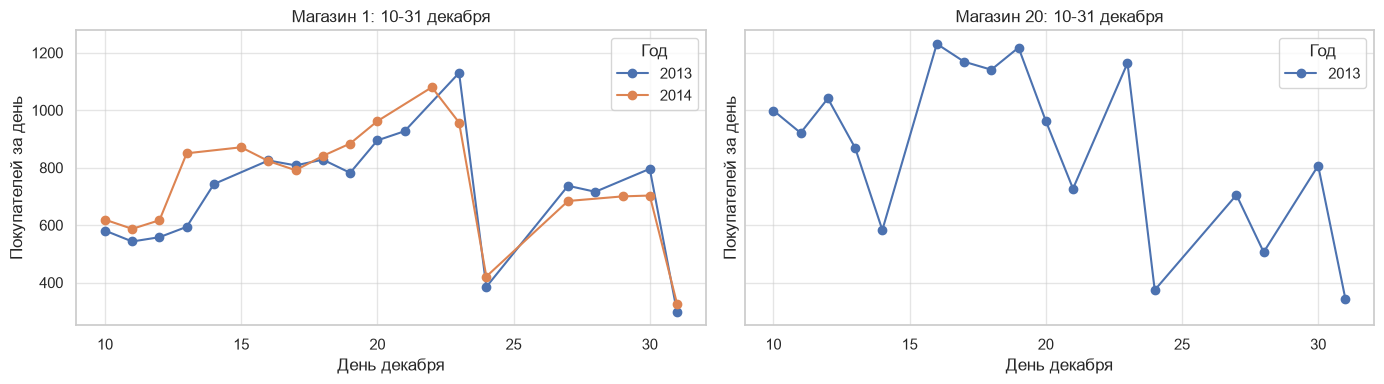

In [19]:
december = open_days[(open_days.index.month == 12) & (open_days.index.day >= 10)]

fig, axes = plt.subplots(1, len(STORE_IDS), figsize=(14, 4), sharey=True)
for ax, store in zip(axes, STORE_IDS):
    store_dec = december[december['Store'] == store]
    for year, part in store_dec.groupby(store_dec.index.year):
        ax.plot(part.index.day, part['Customers'], marker='o', label=year)
    ax.set(title=f'Магазин {store}: 10-31 декабря', xlabel='День декабря', ylabel='Покупателей за день')
    ax.legend(title='Год')
plt.tight_layout()
plt.show()

**Вывод.** Перед Рождеством поток растёт: у магазина 1 с 10 по 23 декабря - с ≈550 до 1000-1150 покупателей, почти вдвое выше обычного. 24 и 31 декабря - предпраздничные дни (Рождество 25 декабря), покупателей в 2-3 раза меньше обычного (300-400). В 2013 и 2014 годах картина почти одинаковая.

**Для модели:** это регулярное событие, а не шум. Нужны признаки близости Рождества (хотя бы «последние две недели декабря») и отдельные флаги для 24 и 31 декабря.

In [20]:
with_flags = data.assign(
    PreHoliday=data.groupby('Store')['StateHoliday'].shift(-1).fillna('0').ne('0')
)
with_flags[with_flags['Open'] == 1].pivot_table(
    index='Store', columns='PreHoliday', values='Customers', aggfunc='mean'
).round(0)

PreHoliday,False,True
Store,,
1,564.00,576.00
20,846.00,927.00


**Вывод.** В день перед госпраздником покупателей больше: +2% у магазина 1 и +10% у магазина 20.

**Для модели:** даты госпраздников известны заранее, поэтому признак «завтра праздник» честный - он не заглядывает в будущее.

### Выбросы

Сравниваем каждый день с другими такими же днями недели того же магазина: выброс - дальше 3 межквартильных размахов от квартилей. Порог строгий, чтобы ловить только сильные отклонения.

In [21]:
by_dow = open_days.groupby(['Store', 'DayOfWeek'])['Customers']
q1 = by_dow.transform('quantile', 0.25)
q3 = by_dow.transform('quantile', 0.75)
iqr = q3 - q1

outliers = open_days[(open_days['Customers'] > q3 + 3 * iqr) | (open_days['Customers'] < q1 - 3 * iqr)]
outliers[['Store', 'DayOfWeek', 'Customers', 'Promo', 'StateHoliday', 'SchoolHoliday']]

,Store,DayOfWeek,Customers,Promo,StateHoliday,SchoolHoliday
Date,,,,,,
2013-03-28,1,4,902,1,0,1
2013-12-23,1,1,1130,0,0,1
2014-12-22,1,1,1080,0,0,1
2014-12-23,1,2,957,0,0,1
2013-12-24,20,2,374,0,0,1
2013-12-31,20,2,343,0,0,1


**Вывод.** Все 6 найденных выбросов - не ошибки выгрузки, а календарные события:

- 2013-03-28, магазин 1 - четверг перед 29 марта - госпраздник;
- 22-23 декабря, магазин 1 - предрождественский пик;
- 24 и 31 декабря, магазин 20 - короткие предпраздничные дни.

Поэтому ничего не удаляем и не обрезаем: такие дни повторяются каждый год, и модель должна уметь их прогнозировать. Вместо удаления добавим признаки: день перед праздником, конец декабря, 24 и 31 декабря. Ошибок выгрузки (задвоенных или обрезанных дней) у этих двух магазинов не видно.

### Ряд для анализа временной структуры

Тест Дики-Фуллера, автокорреляция, Фурье и вейвлеты работают только с регулярным рядом без дыр. Поэтому для этих разделов готовим ряд так:

- закрытые дни (воскресенья, праздники) заполняем линейной интерполяцией между соседними открытыми днями - ноль там означал бы не спрос, а закрытие, и дал бы ложный недельный цикл;
- у магазина 20 берём самый длинный кусок без сбоя выгрузки: интерполировать полгода нельзя.

In [22]:
def continuous_series(store: int) -> pd.Series:
    store_df = data[data['Store'] == store].asfreq('D')
    no_export = store_df['Open'].isna()
    segment_id = no_export.cumsum()
    longest = segment_id[~no_export].value_counts().idxmax()
    segment = store_df[(segment_id == longest) & ~no_export]
    customers = segment['Customers'].where(segment['Open'] == 1)
    return customers.interpolate(method='time', limit_direction='both')


series = {store: continuous_series(store) for store in STORE_IDS}
for store, s in series.items():
    print(f'Магазин {store}: {len(s)} дней, {s.index.min().date()} … {s.index.max().date()}')

Магазин 1: 942 дней, 2013-01-01 … 2015-07-31
Магазин 20: 546 дней, 2013-01-01 … 2014-06-30


### Тест Дики-Фуллера

Проверяет, стационарен ли ряд. Нулевая гипотеза - ряд нестационарен.

p-value < 0.05 - гипотезу отвергаем, ряд стационарен.

In [23]:
rows = []
for store, s in series.items():
        stat, pvalue, used_lags, *_ = adfuller(s, result_object=False)
        rows.append({'Store': store, 'p-value': pvalue, 'Лагов в тесте': used_lags})
pd.DataFrame(rows).round(4)

,Store,p-value,Лагов в тесте
0,1,0.00,21
1,20,0.00,19


**Вывод.** У обоих магазинов p-value < 0.01 уже для самого ряда: гипотезу о нестационарности отвергаем.

**Для модели:** дифференцировать ряд не обязательно, можно прогнозировать сам уровень покупателей. Медленный дрейф уровня учтут скользящие средние.

### Автокорреляция и частичная автокорреляция

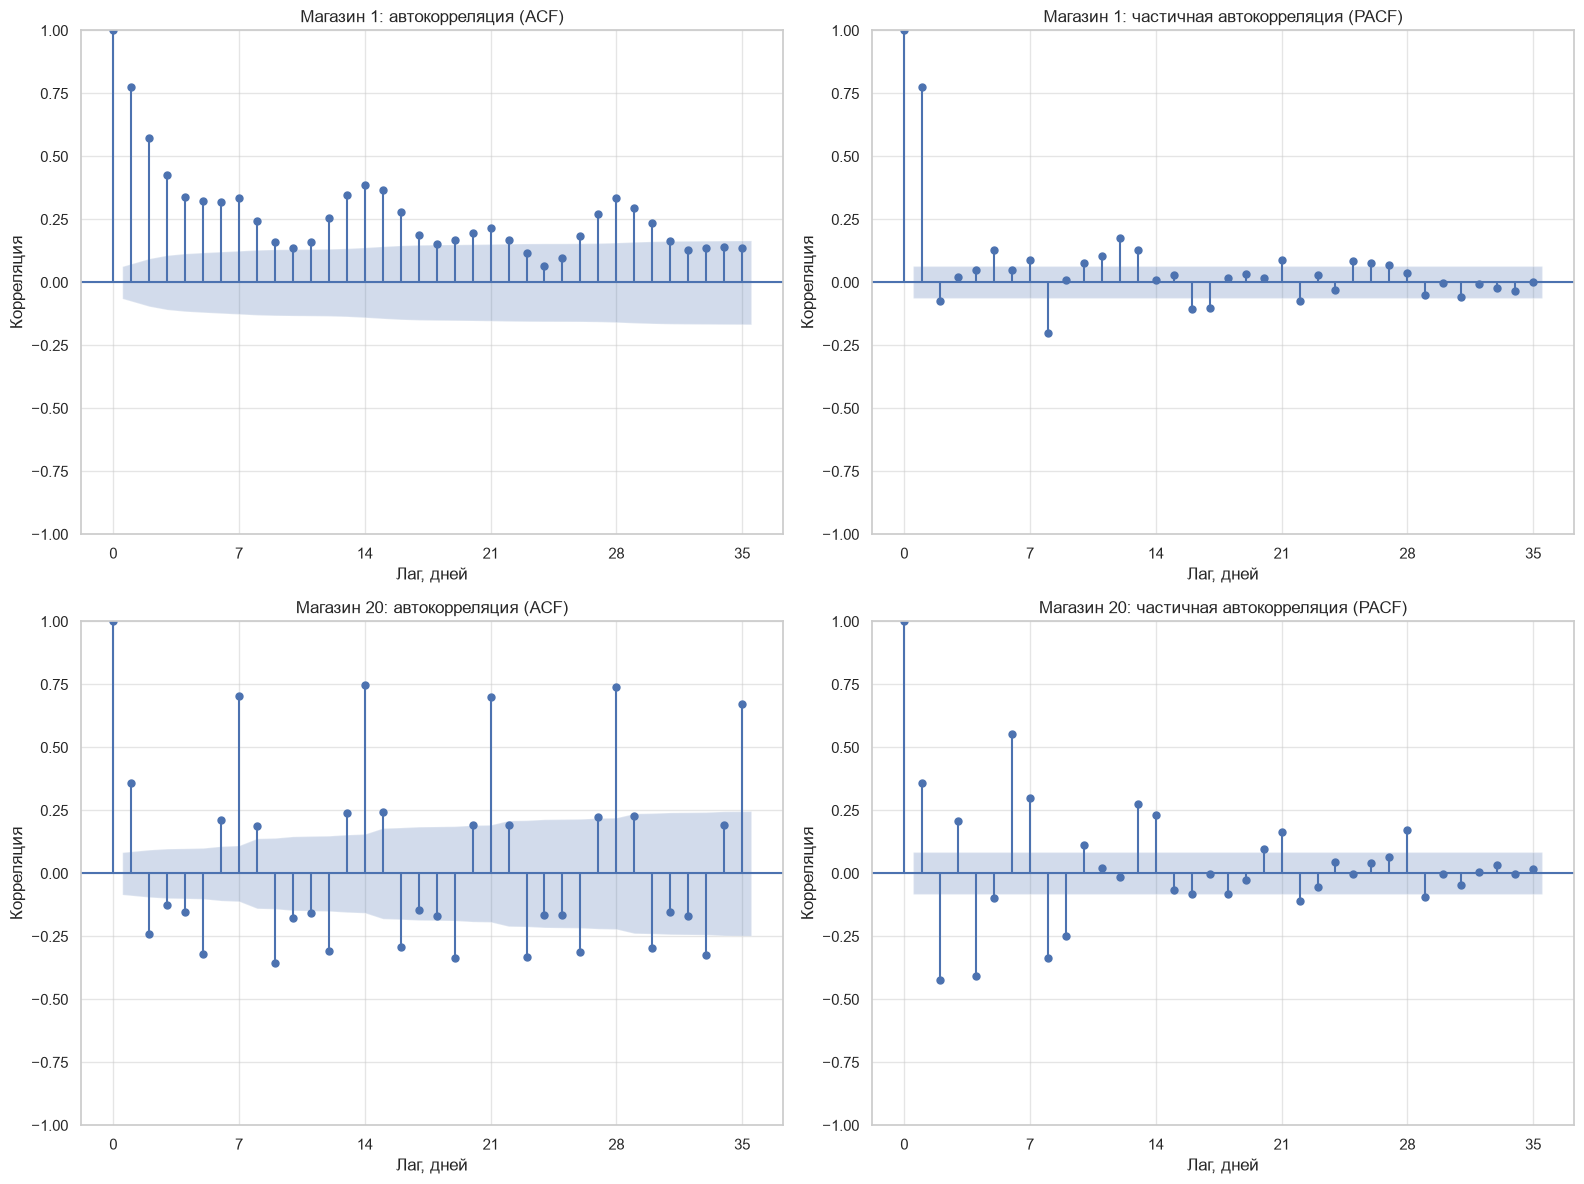

In [24]:
fig, axes = plt.subplots(len(series), 2, figsize=(16, 12))
for row, (store, s) in zip(axes, series.items()):
    plot_acf(s, lags=35, ax=row[0], title=f'Магазин {store}: автокорреляция (ACF)')
    plot_pacf(s, lags=35, ax=row[1], method='ywm', title=f'Магазин {store}: частичная автокорреляция (PACF)')
    for ax in row:
        ax.set(xlabel='Лаг, дней', ylabel='Корреляция')
        ax.set_xticks(range(0, 36, 7))
plt.tight_layout()
plt.show()

**Вывод.**

- У магазина 20 ACF недельный цикл доминирует.
- У магазина 1 пики на лагах 14 и 28 выше, чем на 7. Причина - промо: оно идёт с понедельника по пятницу **через неделю**.
- PACF у магазина 1 обрывается после лага 1 (~ 0.75): соседние дни похожи. У магазина 20 значимы многие лаги до 9, а также 13-14 и 28.

**Для модели:** Короткие лаги с сильной PACF (лаг 1 у магазина 1) помогут только ближним горизонтам, а для дальних главными остаются лаги 7, 14 и 28. Лаг 7 у магазина 1 путает промо-недели, поэтому нужны ещё лаг 14 и `Promo` как признак. Наивный бейзлайн «тот же день неделю назад» у магазина 1 будет заведомо слабым, поэтому модель честнее сравнивать ещё и с бейзлайном «две недели назад».

### Анализ Фурье

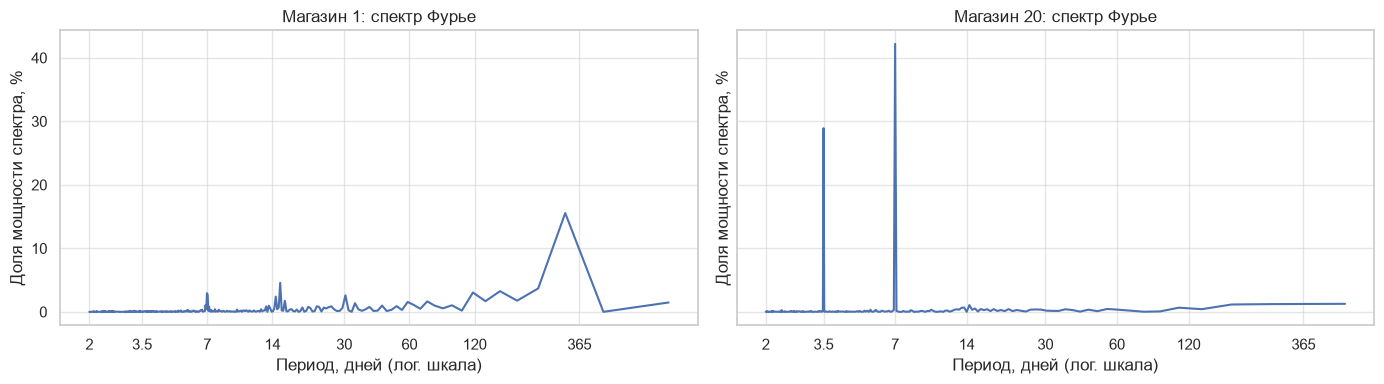

Доля мощности, %
Store Период, дней                  
1     314.00                   15.60
      15.20                     4.60
      235.50                    3.70
      157.00                    3.30
      117.80                    3.00
20    7.00                     42.20
      3.50                     28.90
      546.00                    1.30
      273.00                    1.20
      182.00                    1.20

In [25]:
fig, axes = plt.subplots(1, len(series), figsize=(14, 4), sharey=True)
top_periods = {}
for ax, (store, s) in zip(axes, series.items()):
    values = s.to_numpy() - s.mean()
    power = np.abs(np.fft.rfft(values))[1:] ** 2
    periods = 1 / np.fft.rfftfreq(len(values), d=1)[1:]
    share = power / power.sum() * 100
    ax.plot(periods, share)
    ax.set_xscale('log')
    period_ticks = [2, 3.5, 7, 14, 30, 60, 120, 365]
    ax.set_xticks(period_ticks, [str(p) for p in period_ticks])
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set(title=f'Магазин {store}: спектр Фурье', xlabel='Период, дней (лог. шкала)', ylabel='Доля мощности спектра, %')
    top = np.argsort(share)[::-1][:5]
    top_periods[store] = pd.Series(share[top], index=periods[top].round(1)).round(1)
plt.tight_layout()
plt.show()

pd.concat(top_periods, names=['Store', 'Период, дней']).rename('Доля мощности, %').to_frame()

**Вывод.** Анализ Фурье подтверждает недельную сезонность. У магазина 20 самые сильные пики - период 7 дней и 3.5 дня. У магазина 1 пик на 7 днях на графике тоже есть, но слабый: заметнее пик около 15 дней - двухнедельный цикл промо из раздела «Промо» - и длинные периоды. Длинным периодам доверять нельзя: в данных всего несколько их повторений.

### Вейвлет-анализ

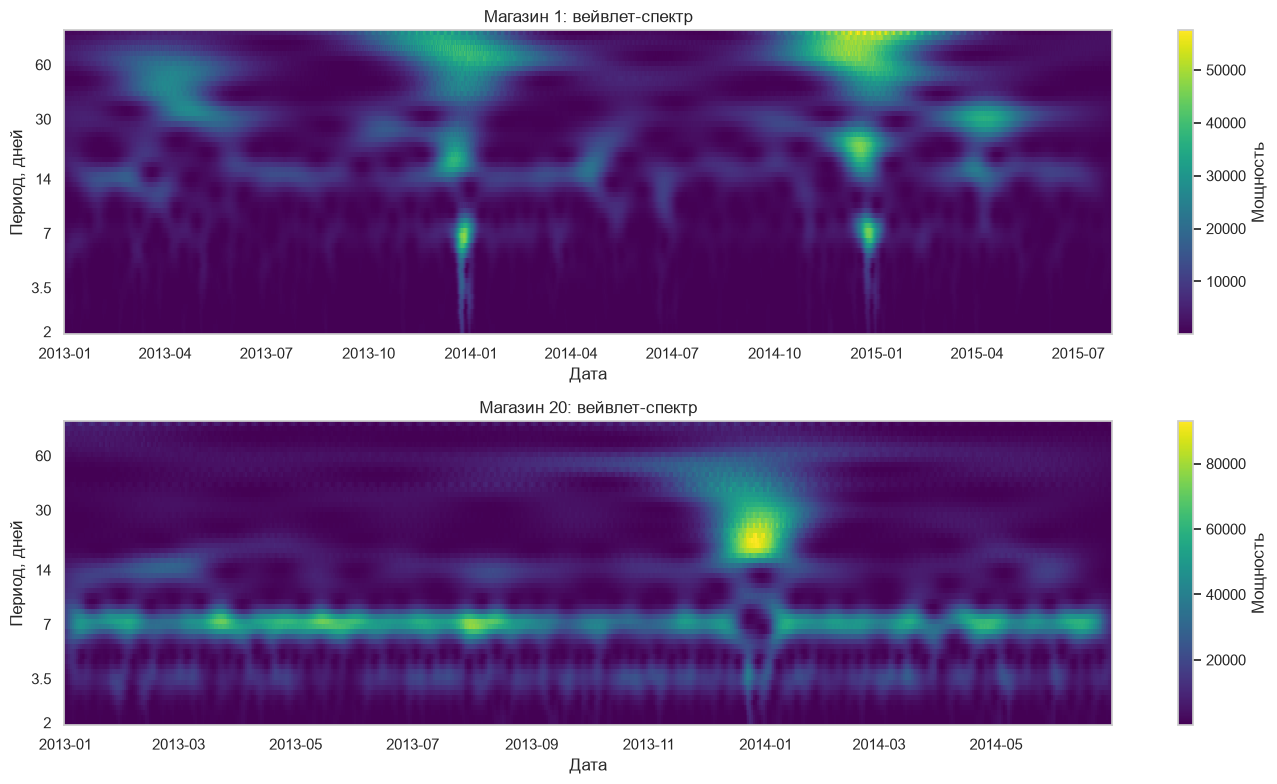

In [26]:
WAVELET = 'cmor1.5-1.0'
wavelet_periods = np.geomspace(2, 90, 60)
scales = pywt.frequency2scale(WAVELET, 1 / wavelet_periods)

fig, axes = plt.subplots(len(series), 1, figsize=(14, 8))
for ax, (store, s) in zip(axes, series.items()):
    coefs, _ = pywt.cwt((s - s.mean()).to_numpy(), scales, WAVELET)
    power = np.abs(coefs) ** 2
    mesh = ax.pcolormesh(s.index, wavelet_periods, power, shading='auto', cmap='viridis')
    ax.set_yscale('log')
    ax.set_yticks([2, 3.5, 7, 14, 30, 60], ['2', '3.5', '7', '14', '30', '60'])
    ax.yaxis.set_minor_locator(plt.NullLocator())
    ax.set(title=f'Магазин {store}: вейвлет-спектр', xlabel='Дата', ylabel='Период, дней')
    fig.colorbar(mesh, ax=ax, label='Мощность')
plt.tight_layout()
plt.show()

**Вывод.** Вейвлет-спектр подтверждает недельную сезонность из раздела «Недельная сезонность».

- У магазина 20 полосы на 7 и 3.5 днях яркие и ровные весь период: недельный цикл стабилен, его можно учить на всей истории.
- У магазина 1 постоянной недельной полосы нет, зато видна пунктирная полоса на периодах 15-20 дней - это чередование промо-недель, тот же пик около 15 дней, что и в спектре Фурье.
- У обоих магазинов в декабре вспыхивают периоды от 7 до 30 дней и выше: предрождественский рост и провалы 24 и 31 декабря ломают обычный ритм.

**Для модели:** декабрь - особый режим, где обычные лаги будут ошибаться сильнее всего, поэтому нужны отдельные признаки конца года. В остальное время структура ряда стабильна, и модель, обученная на прошлом, должна переноситься на будущее.

**Вывод.**

- **Магазин 20:** недельная сезонность сильная (0.70), тренд слабый (0.13). В недельном профиле понедельник-четверг выше тренда на 70.7-156.6 покупателя, пятница ниже на 45.7, суббота ниже на 327.9. Амплитуда недельной компоненты почти не меняется во времени, кроме декабря.
- **Магазин 1:** и тренд (0.33), и недельная сезонность (0.21) объясняют ряд слабо. Тренд не монотонный: каждую зиму он поднимается из-за декабря, а между зимами уровень снижается. Недельный профиль мягкий: суббота +27.9, понедельник +23.6, середина недели до -29.9.
- **Воскресенье в профиле не интерпретируем** (+28.9 и -95.8): воскресенья закрыты, и значения в ряде интерполированы.
- **Остаток:** автокорреляция на лаге 7 слабо отрицательная (-0.15 и -0.10), на лаге 14 около нуля (0.07 и 0.02), то есть недельная компонента забрала почти всю недельную структуру. Самые крупные остатки приходятся на декабрь и праздники: STL их не описывает.

**Для модели:** у магазина 20 основу прогноза даёт недельный профиль, то есть день недели и лаги, кратные 7. У магазина 1 неделя объясняет мало, и решают промо, признаки декабря и праздников и уровень за последние недели. Тренд медленный, поэтому отдельный признак тренда не нужен: его учтут скользящие средние.

## Корреляция признаков с таргетом

Считаем по открытым дням, отдельно для каждого магазина. Кроме исходных колонок, проверяем кандидатов в признаки из выводов EDA:

- лаги 1, 7, 14 и 28 и скользящее среднее со сдвигом 7. На каждый горизонт h будет своя модель
- день перед госпраздником, декабрь, дни недели.

Корреляция Пирсона. Для бинарных признаков она показывает, насколько отличается среднее число покупателей при значении 1 и 0.

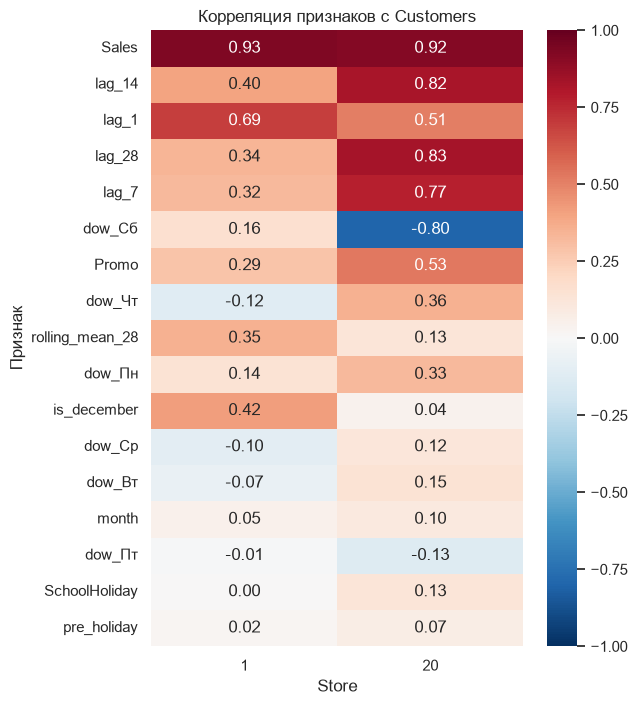

In [29]:
frames = []
for store in STORE_IDS:
    s = data[data['Store'] == store].asfreq('D')
    target = s['Customers'].where(s['Open'] == 1)
    dow = s.index.dayofweek
    frames.append(pd.DataFrame(
        {
            'Store': store,
            'Customers': target,
            'Sales': s['Sales'],
            'Promo': s['Promo'],
            'SchoolHoliday': s['SchoolHoliday'],
            'pre_holiday': s['StateHoliday'].shift(-1).fillna('0').ne('0').astype(int),
            'is_december': (s.index.month == 12).astype(int),
            'month': s.index.month,
            **{f'dow_{name}': (dow == i).astype(int) for i, name in enumerate(DAY_NAMES[:6])},
            'lag_1': target.shift(1),
            'lag_7': target.shift(7),
            'lag_14': target.shift(14),
            'lag_28': target.shift(28),
            'rolling_mean_28': target.shift(7).rolling(28, min_periods=14).mean(),
        },
        index=s.index,
    ))
candidates = pd.concat(frames)
open_rows = candidates[candidates['Customers'].notna()]

target_corr = pd.DataFrame({
    store: group.drop(columns=['Store', 'Customers']).corrwith(group['Customers'])
    for store, group in open_rows.groupby('Store')
})
target_corr = target_corr.loc[target_corr.abs().mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(target_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set(title='Корреляция признаков с Customers', xlabel='Store', ylabel='Признак')
plt.show()

**Вывод.**

- **`Sales` - 0.92-0.93, но это утечка:** выручка за день известна только вместе с числом покупателей за тот же день. В признаки её брать нельзя.
- `lag_1` у магазина 1 - 0.69, сильнее всех остальных лагов (у них 0.32-0.40): вчерашний день хорошо описывает сегодняшний, поэтому прогноз на завтра у этого магазина будет заметно точнее, чем на неделю вперёд. У магазина 20 `lag_1` - 0.51, но недельные лаги сильнее: 0.77-0.83.
- У магазина 1 `lag_14` сильнее `lag_7` (эффект промо, см. автокорреляцию).
- Дни недели важны по-разному: у магазина 20 корреляция субботы −0.80, у магазина 1 эффект дней слабый (до 0.16).
- `Promo`: 0.29 и 0.53 - сильный и честный признак, промо-календарь известен заранее.
- `is_december` у магазина 1 - 0.42, для него это сильнейший честный признак. Номер месяца `month` как число почти бесполезен (0.05-0.10): сезонность не растёт линейно от января к декабрю.
- `SchoolHoliday` и `pre_holiday` - около нуля: дней перед праздниками мало, и эффект в среднем небольшой.

**Для модели:** берём лаги до 28, лаги 7, 14 и 28 - во всех моделях, скользящее среднее со сдвигом, `Promo`, день недели и флаг декабря, а `Sales` исключаем. Корреляция ловит только линейную связь, поэтому слабые признаки вроде `pre_holiday` сразу не выбрасываем: их вклад проверим по важности признаков в модели.

### Итоги EDA для модели

- **Целевая** - `Customers` в открытые дни. Закрытые дни (воскресенья, праздники) - известный заранее график: в прогнозе 0, в обучении и метриках не участвуют.
- **Стратегия прогноза** - отдельная модель на каждый горизонт.
- **Недельная сезонность** - главный фактор, у каждого магазина своя -> лаги 7 и 14 и день недели.
- **Уровень ряда дрейфует** -> скользящие средние за последние недели.
- **Годовая сезонность** - в основном декабрь -> месяц и признаки близости Рождества.
- **Праздники и промо** известны заранее -> флаги «завтра праздник» и `Promo`.
- **Выбросы** -> календарные события, их не удаляем.
- **Сбой выгрузки** у магазина 20 (июль-декабрь 2014) не заполняем нулями: это `NaN` со статусом -1.
- **Метрики:** MAE легко интерпретируема в покупателях внутри магазина, MAPE для сравнения магазинов разного масштаба.

In [30]:
parts = []
for store in STORE_IDS:
    part = data[data['Store'] == store].asfreq('D')
    part['Store'] = store
    parts.append(part)
restored = pd.concat(parts)
restored['DayOfWeek'] = restored.index.dayofweek + 1

check_misses_and_duplicates(restored)
restored.info()

1: 942 строк, ожидается 942
пропущенных дат: 0
дублей дат: 0
--------------------------------------------------
20: 942 строк, ожидается 942
пропущенных дат: 0
дублей дат: 0
--------------------------------------------------
<class 'pandas.DataFrame'>
DatetimeIndex: 1884 entries, 2013-01-01 to 2015-07-31
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Store          1884 non-null   int64  
 1   DayOfWeek      1884 non-null   int32  
 2   Sales          1700 non-null   float64
 3   Customers      1700 non-null   float64
 4   Open           1700 non-null   float64
 5   Promo          1700 non-null   float64
 6   StateHoliday   1700 non-null   str    
 7   SchoolHoliday  1700 non-null   float64
dtypes: float64(5), int32(1), int64(1), str(1)
memory usage: 125.1 KB
